In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from pansharpening import PANDataset
from pan_ctv111 import PANTVCTV111
from torchvision import transforms
from math import sqrt

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [3]:
#val_transform  =  transforms.Compose([ transforms.CenterCrop(crop_size)])
dataset =PANDataset(root_dir=data_path, split='train' ,transform=None,normalize=True,scale=4,sigma=0.1,sigma1 = 0.01,device=device,size=None,seed =seed)

In [4]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [5]:
# Matrice de transformation
Y_H = dataset.simulate_low_res_hsi(X)  
Y_M = dataset.get_panchromatic(X)

In [7]:
A,A_adj, R, R_adj = dataset.get_operators()

solver_gp = PANTVCTV111(
    A=A,
    Aadj=A_adj,
    spectral_op = R,
    spectral_op_t = R_adj,
    max_iter=200,
    lmbda=1e-2,
    lmbda_m=2,
    tol=1e-7,
    scale=dataset.scale,
    p = 1,
    q = 1,
    r = 1,
    verbose=True
    
)

In [8]:
U_gp,costs_gp = solver_gp(Y_H, Y_M)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------


AssertionError: Input and filter must be 5D tensors

In [12]:
U_gp.shape

torch.Size([1, 31, 1040, 1392])

/tmp/ipykernel_2213324/1432506621.py:9: RuntimeWarning: invalid value encountered in divide
  z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())


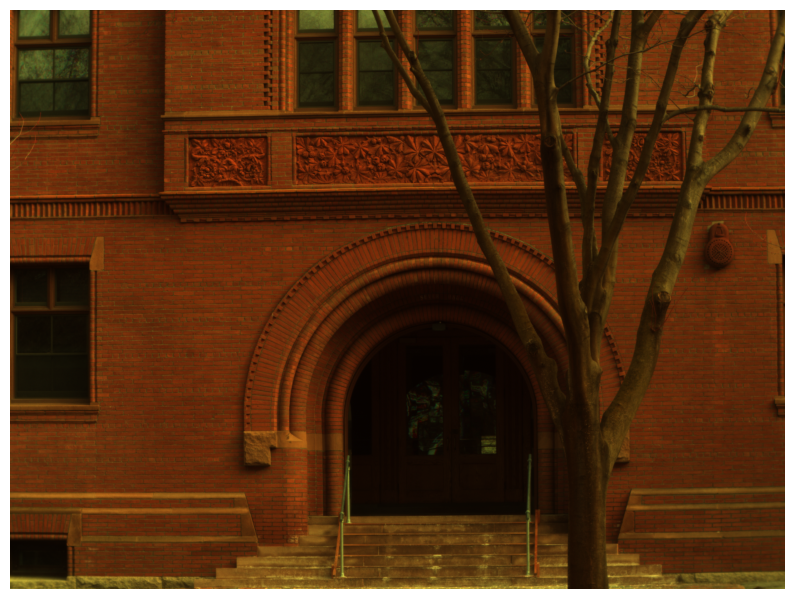

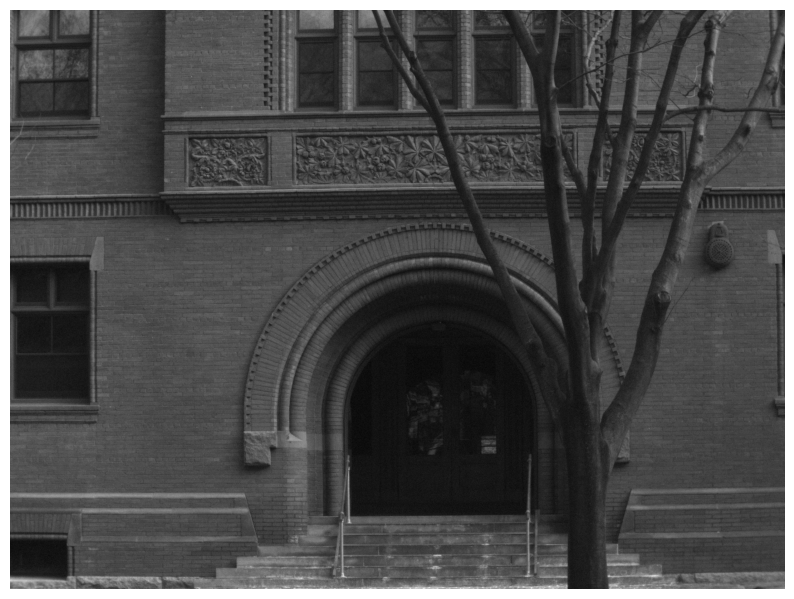

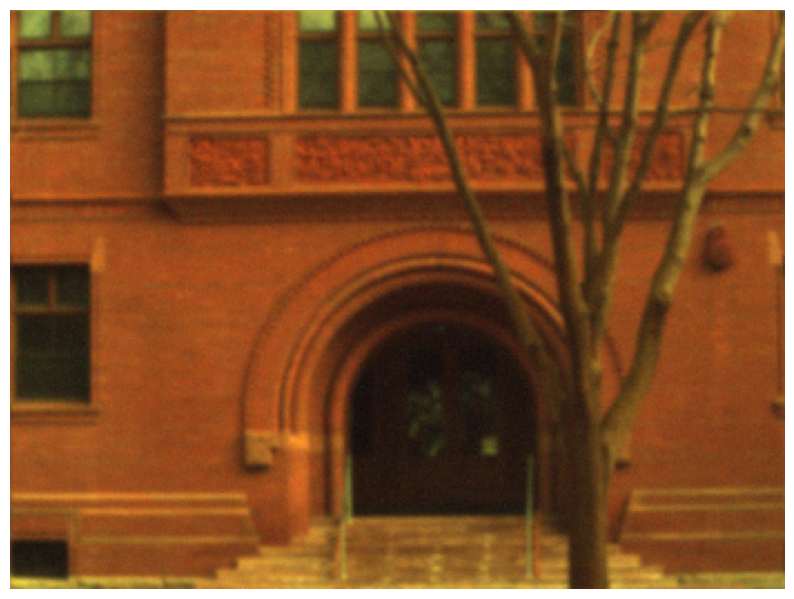

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


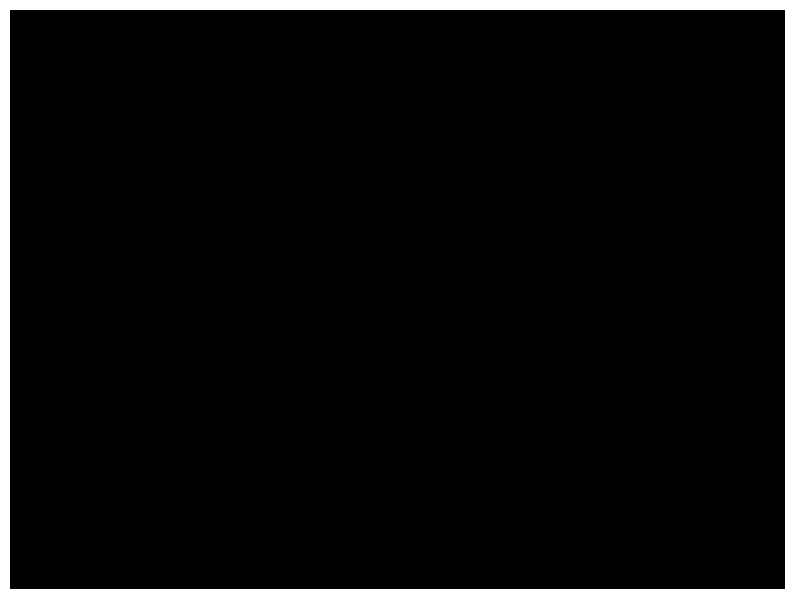

In [13]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_gp[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()